In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
df = pd.read_csv('cars.csv')



In [2]:
# basic inspection
print("Basic inspection results:")
print(f"Shape: {df.shape}")
print(f'Columns: {list(df.columns)}')

print("\nfirst 5 rows")
print(df.head())

Basic inspection results:
Shape: (958, 26)
Columns: ['source', 'url', 'title', 'price_raw', 'price_value', 'currency', 'make', 'model', 'trim', 'year', 'mileage_raw', 'mileage_km', 'engine_raw', 'engine_cc', 'fuel', 'transmission', 'drive', 'body_type', 'color', 'steering', 'doors', 'seats', 'stock_no', 'chassis_no', 'location', 'scraped_at_utc']

first 5 rows
      source                                               url  \
0  beforward  https://www.beforward.jp/pt/beforward_mozambique   
1  beforward     https://www.beforward.jp/fr/beforward_drcongo   
2  beforward     https://www.beforward.jp/fr/beforward_burundi   
3  beforward      https://www.beforward.jp/pt/beforward_angola   
4  beforward      https://www.beforward.jp/ru/beforward_russia   

                                               title  \
0  Japanese Used Cars for Sale near Me - BE FORWA...   
1  Japanese Used Cars for Sale near Me - BE FORWA...   
2  Japanese Used Cars for Sale near Me - BE FORWA...   
3  Japanese Used

In [3]:
print("Data types: ")
print(df.dtypes)

Data types: 
source                str
url                   str
title                 str
price_raw             str
price_value       float64
currency              str
make                  str
model                 str
trim                  str
year              float64
mileage_raw           str
mileage_km        float64
engine_raw            str
engine_cc         float64
fuel                  str
transmission          str
drive                 str
body_type             str
color                 str
steering              str
doors             float64
seats             float64
stock_no              str
chassis_no            str
location              str
scraped_at_utc        str
dtype: object


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   source          958 non-null    str    
 1   url             958 non-null    str    
 2   title           958 non-null    str    
 3   price_raw       958 non-null    str    
 4   price_value     958 non-null    float64
 5   currency        956 non-null    str    
 6   make            958 non-null    str    
 7   model           958 non-null    str    
 8   trim            13 non-null     str    
 9   year            951 non-null    float64
 10  mileage_raw     938 non-null    str    
 11  mileage_km      0 non-null      float64
 12  engine_raw      954 non-null    str    
 13  engine_cc       5 non-null      float64
 14  fuel            937 non-null    str    
 15  transmission    938 non-null    str    
 16  drive           937 non-null    str    
 17  body_type       14 non-null     str    
 18  c

In [5]:
print("summary statistics: ")
print(df.describe().round(2))

summary statistics: 
       price_value     year  mileage_km  engine_cc   doors   seats
count       958.00   951.00         0.0        5.0  936.00  244.00
mean      15944.06  2017.60         NaN        1.0    4.72    5.07
std       14285.46     5.24         NaN        0.0    0.70    1.08
min           6.00  1988.00         NaN        1.0    2.00    2.00
25%        7020.00  2015.00         NaN        1.0    5.00    5.00
50%       12935.00  2018.00         NaN        1.0    5.00    5.00
75%       20560.00  2021.00         NaN        1.0    5.00    5.00
max      159250.00  2026.00         NaN        1.0    5.00    8.00


In [6]:
# missing values
print("Missing values: ")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'count' : missing,
    'percentage' : missing_pct
})

print(missing_df[missing_df['count'] > 0].sort_values(by='percentage', ascending=False))

Missing values: 
              count  percentage
mileage_km      958  100.000000
engine_cc       953   99.478079
trim            945   98.643006
body_type       944   98.538622
seats           714   74.530271
doors            22    2.296451
stock_no         21    2.192067
drive            21    2.192067
fuel             21    2.192067
color            21    2.192067
steering         20    2.087683
mileage_raw      20    2.087683
transmission     20    2.087683
chassis_no       20    2.087683
year              7    0.730689
engine_raw        4    0.417537
currency          2    0.208768


In [7]:
# target distribution
TARGET = 'price_value'
print('Target distribution')
print(df[TARGET].describe().round(2))

Target distribution
count       958.00
mean      15944.06
std       14285.46
min           6.00
25%        7020.00
50%       12935.00
75%       20560.00
max      159250.00
Name: price_value, dtype: float64


In [8]:
df.head()

,source,url,title,price_raw,price_value,currency,make,model,trim,year,...,drive,body_type,color,steering,doors,seats,stock_no,chassis_no,location,scraped_at_utc
0,beforward,https://www.beforward.jp/pt/beforward_mozambique,Japanese Used Cars for Sale near Me - BE FORWA...,6,6.0,NaN,ALL PAYMENTS SHOULD BE MADE DIRECTLY TO BE FOR...,BEFORWARD_MOZAMBIQUE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Maputo Office,SUV Van Bus Truck Sedan Coupe Wagon Pick up Mi...,2026-05-17T21:05:45.478527+00:00
1,beforward,https://www.beforward.jp/fr/beforward_drcongo,Japanese Used Cars for Sale near Me - BE FORWA...,"Moins de $500 $500 - $1,000 $1,000 - $1,500 $1...",500.0,USD,TOYOTA NISSAN HONDA MAZDA MITSUBISHI SUBARU SU...,BEFORWARD_DRCONGO,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Japan (307,411) Korea (197,964) Thailand (7,09...",2026-05-17T21:05:49.100533+00:00
2,beforward,https://www.beforward.jp/fr/beforward_burundi,Japanese Used Cars for Sale near Me - BE FORWA...,"Moins de $500 $500 - $1,000 $1,000 - $1,500 $1...",500.0,USD,TOYOTA NISSAN HONDA MAZDA MITSUBISHI SUBARU SU...,BEFORWARD_BURUNDI,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Japan (307,411) Korea (197,964) Thailand (7,09...",2026-05-17T21:05:53.078050+00:00
3,beforward,https://www.beforward.jp/pt/beforward_angola,Japanese Used Cars for Sale near Me - BE FORWA...,6,6.0,NaN,ALL PAYMENTS SHOULD BE MADE DIRECTLY TO BE FOR...,CC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUV Van Bus Truck Sedan Coupe Wagon Pick up Mi...,2026-05-17T21:05:56.688580+00:00
4,beforward,https://www.beforward.jp/ru/beforward_russia,Japanese Used Cars for Sale near Me - BE FORWA...,"Дешевле $500 $500 - $1,000 $1,000 - $1,500 $1,...",500.0,USD,TOYOTA NISSAN HONDA MAZDA MITSUBISHI SUBARU SU...,About BE FORWARD Auto Parts Как купить How to ...,About BE FORWARD Auto Parts Как купить How to ...,2011.0,...,About BE FORWARD Auto Parts Как купить How to ...,About BE FORWARD Auto Parts Как купить How to ...,About BE FORWARD Auto Parts Как купить How to ...,About BE FORWARD Auto Parts Как купить How to ...,NaN,NaN,About BE FORWARD Auto Parts Как купить How to ...,About BE FORWARD Auto Parts Как купить How to ...,"Japan (307,411) Korea (197,964) Thailand (7,09...",2026-05-17T21:06:00.081771+00:00


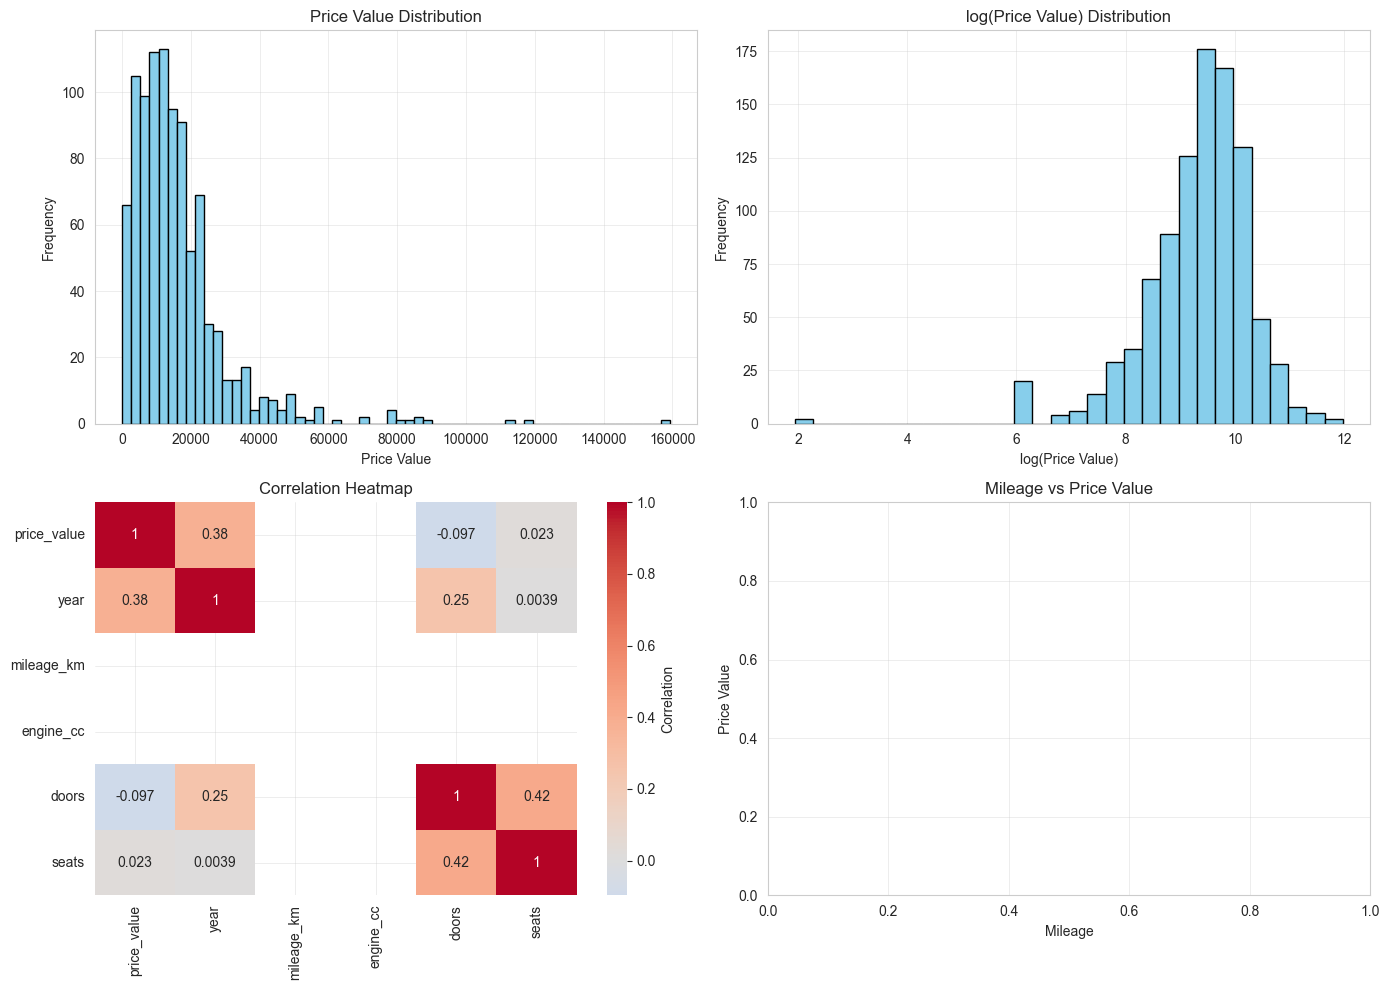


✅ EDA Visualizations complete


In [9]:
# visua;izations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
df[TARGET].hist(ax=axes[0, 0], bins=60, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Price Value Distribution')
axes[0, 0].set_xlabel('Price Value')
axes[0, 0].set_ylabel('Frequency')

# Target log scale distribution
axes[0, 1].hist(np.log1p(df[TARGET]), bins = 30, color = 'skyblue', edgecolor = 'black')
axes[0, 1].set_title('log(Price Value) Distribution')
axes[0, 1].set_xlabel('log(Price Value)')
axes[0, 1].set_ylabel('Frequency')


# correlation heatmap
num_cols_temp = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols_temp].corr(), ax = axes[1,0], annot=True, cmap='coolwarm', center = 0, cbar_kws = {'label': 'Correlation'})
axes[1, 0].set_title('Correlation Heatmap')

# scatter plot
sns.scatterplot(x='mileage_km', y=TARGET, data= df, ax=axes[1, 1], color='coral', edgecolor='black')
axes[1, 1].set_title('Mileage vs Price Value')
axes[1, 1].set_xlabel('Mileage')
axes[1, 1].set_ylabel('Price Value')

plt.tight_layout()
plt.show()

print("\n✅ EDA Visualizations complete")

In [10]:
# EDA summary
print("=" * 60)
print("EDA Summary:")
print("=" * 60)
print(f"1.Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\n2. Missing values: {missing_df[missing_df['count'] > 0].sort_values(by='percentage', ascending=False)}")
print(f"\n4. Target variable '{TARGET}' distribution:")
print(df[TARGET].describe().round(2))
print("\n5. columns to drop : mileage_km, engine_cc, trim, body_type, scraped_at,")

EDA Summary:
1.Dataset shape: 958 rows x 26 columns

2. Missing values:               count  percentage
mileage_km      958  100.000000
engine_cc       953   99.478079
trim            945   98.643006
body_type       944   98.538622
seats           714   74.530271
doors            22    2.296451
stock_no         21    2.192067
drive            21    2.192067
fuel             21    2.192067
color            21    2.192067
steering         20    2.087683
mileage_raw      20    2.087683
transmission     20    2.087683
chassis_no       20    2.087683
year              7    0.730689
engine_raw        4    0.417537
currency          2    0.208768

4. Target variable 'price_value' distribution:
count       958.00
mean      15944.06
std       14285.46
min           6.00
25%        7020.00
50%       12935.00
75%       20560.00
max      159250.00
Name: price_value, dtype: float64

5. columns to drop : mileage_km, engine_cc, trim, body_type, scraped_at,


In [11]:
df['seats'].unique()

array([nan,  5.,  8.,  7.,  4.,  2.,  6.])

In [12]:
df_clean = df.copy()

In [13]:
df_clean.to_csv('df_clean.csv', index=False)

In [14]:
import re
from urllib.parse import urlparse

import numpy as np
import pandas as pd

# -----------------------------
# Config
# -----------------------------
DROP_COLS = [
    "mileage_km",
    "engine_cc",
    "trim",
    "body_type",
    "scraped_at_utc",
    "source",
]

REF_YEAR = 2026  # set this to your preferred reference year

MAKE_SLUG_MAP = {
    "toyota": "TOYOTA",
    "nissan": "NISSAN",
    "honda": "HONDA",
    "mazda": "MAZDA",
    "mitsubishi": "MITSUBISHI",
    "suzuki": "SUZUKI",
    "subaru": "SUBARU",
    "isuzu": "ISUZU",
    "daihatsu": "DAIHATSU",
    "lexus": "LEXUS",
    "audi": "AUDI",
    "bmw": "BMW",
    "chevrolet": "CHEVROLET",
    "fiat": "FIAT",
    "ford": "FORD",
    "jaguar": "JAGUAR",
    "jeep": "JEEP",
    "land-rover": "LAND ROVER",
    "landrover": "LAND ROVER",
    "mercedes-benz": "MERCEDES-BENZ",
    "mini": "MINI",
    "porsche": "PORSCHE",
    "renault": "RENAULT",
    "smart": "SMART",
    "tesla": "TESLA",
    "volkswagen": "VOLKSWAGEN",
    "volvo": "VOLVO",
    "alfa-romeo": "ALFA ROMEO",
    "amg": "AMG",
    "hino": "HINO",
    "peugeot": "PEUGEOT",
    "maserati": "MASERATI",
}

COUNTRY_ALIAS = {
    "mozambique": "Mozambique",
    "angola": "Angola",
    "burundi": "Burundi",
    "chile": "Chile",
    "paraguay": "Paraguay",
    "guatemala": "Guatemala",
    "costarica": "Costa Rica",
    "dominicanrepublic": "Dominican Republic",
    "russia": "Russia",
    "drcongo": "Democratic Republic of the Congo",
    "rdcongo": "Democratic Republic of the Congo",
    "democraticrepublicofthecongo": "Democratic Republic of the Congo",
}

JAPAN_LOCATIONS = {
    "YOKOHAMA",
    "NAGOYA",
    "OSAKA",
    "KOBE",
    "KYOTO",
    "KYUSHU",
    "HOKKAIDO",
    "NIIGATA",
    "TOYAMA",
}

VIN_REGION_MAP = {
    "J": "Japan",
    "K": "Korea",
    "S": "United Kingdom",
    "W": "Germany",
    "1": "USA",
    "2": "Canada",
    "3": "Mexico",
    "L": "China",
    "V": "France/Spain",
    "Z": "Italy",
    "Y": "Sweden/Finland",
}

BODY_KEYWORD_MODELS = {
    "truck_pickup": {
        "hilux",
        "l200",
        "ranger",
        "navara",
        "d-max",
        "d max",
        "carry truck",
        "clipper truck",
        "elf truck",
        "canter",
        "fighter",
        "titan",
        "rodeo",
        "amarok",
    },
    "van": {
        "hiace van",
        "regiusace van",
        "townace van",
        "probox van",
        "succeed van",
        "pixis van",
        "vanette van",
        "n-van",
        "every",
        "clipper van",
    },
    "wagon": {
        "corolla touring",
        "corolla touring wagon",
        "legacy touring wagon",
        "mark ii blit",
        "passat variant",
        "mini clubman",
    },
    "convertible_roadster": {
        "roadster",
        "copen",
        "boxster",
        "tt roadster",
        "mx-5",
    },
}

# -----------------------------
# Helpers
# -----------------------------
def path_parts(url):
    try:
        return [p for p in urlparse(str(url)).path.split("/") if p]
    except Exception:
        return []

def normalize_country(text):
    if pd.isna(text):
        return np.nan
    s = str(text).strip()
    key = re.sub(r"[^a-z0-9]", "", s.lower())
    return COUNTRY_ALIAS.get(key, s.title())

def slug_to_label(slug):
    if pd.isna(slug):
        return np.nan
    s = str(slug).replace("-", " ").replace("_", " ").strip()
    if not s:
        return np.nan
    return s.title()

def slug_to_make(slug):
    if pd.isna(slug):
        return np.nan
    s = str(slug).strip().lower()
    return MAKE_SLUG_MAP.get(s, slug_to_label(s).upper())

def get_page_type(url):
    parts = path_parts(url)

    # listing URLs look like /toyota/alphard/cd058878/id/15010299/
    if len(parts) >= 4 and parts[-2] == "id" and str(parts[-1]).isdigit():
        return "listing"

    if "support" in parts:
        return "support"
    if "testimonials" in parts:
        return "testimonial"
    if "beforward_certified_agents" in parts:
        return "agent"
    if any(p.startswith("beforward_") for p in parts):
        return "country_landing"

    return "other"

def extract_market_country(row):
    title = str(row.get("title", ""))
    parts = path_parts(row.get("url", ""))

    # from URL like /pt/beforward_mozambique
    for p in parts:
        if p.startswith("beforward_"):
            return normalize_country(p.replace("beforward_", ""))

    # from title like "... - BE FORWARD Mozambique"
    if "Used Cars for Sale near Me - BE FORWARD " in title:
        return normalize_country(title.split("BE FORWARD ", 1)[1])

    return np.nan

def extract_url_make_model(url):
    parts = path_parts(url)
    if get_page_type(url) != "listing" or len(parts) < 2:
        return np.nan, np.nan
    return slug_to_make(parts[0]), slug_to_label(parts[1])

def extract_title_year(title):
    m = re.search(r"BE FORWARD\s*:\s*(\d{4})", str(title))
    return float(m.group(1)) if m else np.nan

def extract_title_model(title, make_clean):
    s = re.sub(r"^BE FORWARD\s*:\s*\d{4}\s+", "", str(title)).strip()
    if pd.notna(make_clean):
        s = re.sub(r"^" + re.escape(str(make_clean)) + r"\s+", "", s, flags=re.I)
    return s if s else np.nan

def looks_like_model_code(x):
    if pd.isna(x):
        return False
    s = str(x).strip()
    return bool(re.fullmatch(r"[A-Z0-9\-]{3,25}", s))

def normalize_stock_country(location):
    if pd.isna(location):
        return np.nan
    s = str(location).strip().upper()

    if s in JAPAN_LOCATIONS:
        return "Japan"
    if s == "UNITED KINGDOM":
        return "United Kingdom"
    if s == "SINGAPORE":
        return "Singapore"
    if s == "AUSTRALIA":
        return "Australia"

    return str(location).strip().title()

def fuel_group(x):
    s = str(x).strip().lower()
    if s in {"", "nan", "none"}:
        return np.nan
    if "electric" in s:
        return "Electric"
    if "hybrid" in s and "diesel" in s:
        return "Hybrid(Diesel)"
    if "hybrid" in s:
        return "Hybrid(Petrol)"
    if "diesel" in s:
        return "Diesel"
    if "petrol" in s or "gasoline" in s:
        return "Petrol"
    return "Other"

def transmission_group(x):
    s = str(x).strip().lower()
    if s in {"", "nan", "none"}:
        return np.nan
    if "cvt" in s:
        return "CVT"
    if "manual" in s:
        return "Manual"
    if "automatic" in s:
        return "Automatic"
    return "Other"

def drive_group(x):
    s = str(x).strip().lower()
    if s in {"", "nan", "none"}:
        return np.nan
    if "4wheel" in s or "4wd" in s or "awd" in s:
        return "4WD"
    if "2wheel" in s or "2wd" in s:
        return "2WD"
    return "Other"

def steering_group(x):
    s = str(x).strip().lower()
    if s in {"right", "right hand"}:
        return "Right"
    if s in {"left", "left hand"}:
        return "Left"
    return np.nan

def clean_chassis(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    return s if s else np.nan

def is_vin(x):
    if pd.isna(x):
        return False
    s = re.sub(r"[^A-Za-z0-9]", "", str(x).upper())
    return len(s) == 17

def vin_region(x):
    if not is_vin(x):
        return np.nan
    s = re.sub(r"[^A-Za-z0-9]", "", str(x).upper())
    return VIN_REGION_MAP.get(s[0], "Other")

def body_guess(row):
    text = " ".join(
        [
            str(row.get("url_model", "")),
            str(row.get("model_clean", "")),
            str(row.get("title", "")),
        ]
    ).lower()

    doors = row.get("doors_num")
    seats = row.get("seats_num")
    drive = row.get("drive_group")

    for body, keywords in BODY_KEYWORD_MODELS.items():
        if any(k in text for k in keywords):
            return body

    if "truck" in text or "pickup" in text:
        return "truck_pickup"
    if "van" in text:
        return "van"
    if "wagon" in text:
        return "wagon"
    if "roadster" in text or "convertible" in text:
        return "convertible_roadster"

    if pd.notna(seats) and seats >= 7:
        return "mpv_minivan"
    if pd.notna(doors) and doors <= 2:
        return "coupe_roadster_like"
    if pd.notna(doors) and doors == 4 and pd.notna(seats) and seats <= 5:
        return "sedan_like"
    if pd.notna(doors) and doors >= 5 and drive == "4WD":
        return "suv_crossover_like"

    return "unknown"

# -----------------------------
# Main feature engineering
# -----------------------------
def engineer_features(csv_path):
    df_clean = pd.read_csv(csv_path)
    df_clean = df_clean.drop(columns=DROP_COLS, errors="ignore").copy()

    # Basic row classification
    df_clean["page_type"] = df_clean["url"].map(get_page_type)
    df_clean["is_listing"] = df_clean["page_type"].eq("listing")
    df_clean["market_country"] = df_clean.apply(extract_market_country, axis=1)

    # URL-derived vehicle identity
    url_make_model = df_clean["url"].apply(extract_url_make_model)
    df_clean["url_make"] = url_make_model.map(lambda x: x[0] if isinstance(x, tuple) else np.nan)
    df_clean["url_model"] = url_make_model.map(lambda x: x[1] if isinstance(x, tuple) else np.nan)

    # Clean vehicle fields
    df_clean["title_year"] = df_clean["title"].map(extract_title_year)
    df_clean["year_clean"] = pd.to_numeric(df_clean["year"], errors="coerce").fillna(df_clean["title_year"])

    df_clean["make_clean"] = np.where(df_clean["is_listing"], df_clean["url_make"], np.nan)
    df_clean["model_clean"] = np.where(
        df_clean["is_listing"],
        df_clean.apply(lambda r: extract_title_model(r["title"], r["make_clean"]), axis=1),
        np.nan,
    )

    # raw 'model' column looks like model code in listing rows
    df_clean["model_code"] = np.where(
        df_clean["is_listing"] & df_clean["model"].map(looks_like_model_code),
        df_clean["model"],
        np.nan,
    )

    df_clean["make_model"] = (
        df_clean["make_clean"].fillna("").str.strip() + " " + df_clean["model_clean"].fillna("").str.strip()
    ).str.strip()
    df_clean.loc[df_clean["make_model"] == "", "make_model"] = np.nan

    # Price
    df_clean["price_value"] = pd.to_numeric(df_clean["price_value"], errors="coerce")
    df_clean["has_valid_price"] = df_clean["price_value"].gt(0)
    df_clean["price_log"] = np.log1p(df_clean["price_value"])

    df_clean["price_bucket"] = pd.cut(
        df_clean["price_value"],
        bins=[0, 3000, 7000, 15000, 30000, np.inf],
        labels=["budget", "low_mid", "mid", "upper_mid", "premium"],
        include_lowest=True,
    )

    # Age
    df_clean["vehicle_age"] = np.where(
        df_clean["year_clean"].between(1950, REF_YEAR),
        REF_YEAR - df_clean["year_clean"],
        np.nan,
    )

    df_clean["age_bucket"] = pd.cut(
        df_clean["vehicle_age"],
        bins=[-1, 1, 3, 5, 10, 20, 100],
        labels=["0-1", "2-3", "4-5", "6-10", "11-20", "20+"],
    )

    # Normalize categorical fields
    df_clean["fuel_group"] = df_clean["fuel"].map(fuel_group)
    df_clean["is_hybrid"] = df_clean["fuel_group"].str.contains("Hybrid", na=False)
    df_clean["is_electric"] = df_clean["fuel_group"].eq("Electric")
    df_clean["is_electrified"] = df_clean["is_hybrid"] | df_clean["is_electric"]

    df_clean["transmission_group"] = df_clean["transmission"].map(transmission_group)
    df_clean["drive_group"] = df_clean["drive"].map(drive_group)
    df_clean["steering_group"] = df_clean["steering"].map(steering_group)

    # Numeric convenience columns
    df_clean["doors_num"] = pd.to_numeric(df_clean["doors"], errors="coerce")
    df_clean["seats_num"] = pd.to_numeric(df_clean["seats"], errors="coerce")

    df_clean["price_per_seat"] = np.where(
        df_clean["seats_num"].gt(0), df_clean["price_value"] / df_clean["seats_num"], np.nan
    )
    df_clean["price_per_door"] = np.where(
        df_clean["doors_num"].gt(0), df_clean["price_value"] / df_clean["doors_num"], np.nan
    )

    # Location / stock geography
    df_clean["stock_country"] = df_clean["location"].map(normalize_stock_country)
    df_clean["is_overseas_stock"] = df_clean["stock_country"].ne("Japan")

    # Stock / chassis features
    df_clean["stock_prefix"] = df_clean["stock_no"].astype(str).str.extract(r"^([A-Za-z]+)", expand=False)
    df_clean["stock_seq"] = pd.to_numeric(
        df_clean["stock_no"].astype(str).str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )

    df_clean["chassis_no_clean"] = df_clean["chassis_no"].map(clean_chassis)
    df_clean["chassis_prefix"] = df_clean["chassis_no_clean"].astype(str).str.extract(
        r"^([A-Za-z0-9]+)", expand=False
    )
    df_clean["is_vin"] = df_clean["chassis_no_clean"].map(is_vin)
    df_clean["vin_region"] = df_clean["chassis_no_clean"].map(vin_region)
    df_clean["frame_no_type"] = np.select(
        [
            df_clean["is_vin"],
            df_clean["chassis_no_clean"].notna(),
        ],
        [
            "VIN",
            "FrameNo",
        ],
        default=None,
    )

    # Optional: better body-style proxy
    df_clean["body_guess"] = df_clean.apply(body_guess, axis=1)

    # Data completeness / quality
    quality_cols = [
        "title",
        "price_value",
        "year_clean",
        "fuel_group",
        "transmission_group",
        "drive_group",
        "steering_group",
        "stock_no",
        "chassis_no_clean",
        "location",
    ]
    df_clean["completeness_score"] = df_clean[quality_cols].notna().sum(axis=1) / len(quality_cols)

    # Price rank inside make/model
    mask = (
        df_clean["is_listing"]
        & df_clean["price_value"].notna()
        & df_clean["make_clean"].notna()
        & df_clean["model_clean"].notna()
    )

    df_clean.loc[mask, "price_rank_within_make_model"] = (
        df_clean.loc[mask]
        .groupby(["make_clean", "model_clean"])["price_value"]
        .rank(pct=True)
    )

    df_clean.loc[mask, "price_rank_within_make_model_year"] = (
        df_clean.loc[mask]
        .groupby(["make_clean", "model_clean", "year_clean"])["price_value"]
        .rank(pct=True)
    )

    return df_clean

# -----------------------------
# Usage
# -----------------------------
df_clean = engineer_features("df_clean.csv")

# Keep only actual vehicle listings if needed
df_listings = df_clean[df_clean["is_listing"]].copy()

# Save
df_clean.to_csv("beforward_engineered.csv", index=False)
df_listings.to_csv("beforward_engineered_listings_only.csv", index=False)

print("All rows:", df_clean.shape)
print("Listing rows:", df_listings.shape)
print(df_listings[
    [
        "title",
        "page_type",
        "market_country",
        "stock_country",
        "make_clean",
        "model_clean",
        "model_code",
        "year_clean",
        "vehicle_age",
        "price_value",
        "price_bucket",
        "fuel_group",
        "transmission_group",
        "drive_group",
        "body_guess",
    ]
].head(10))

All rows: (958, 60)
Listing rows: (936, 60)
                                      title page_type market_country  \
22         BE FORWARD : 2021 TOYOTA Alphard   listing            NaN   
23         BE FORWARD : 2020 TOYOTA Alphard   listing            NaN   
24         BE FORWARD : 2020 TOYOTA Alphard   listing            NaN   
25         BE FORWARD : 2020 TOYOTA Alphard   listing            NaN   
26         BE FORWARD : 2019 TOYOTA Alphard   listing            NaN   
27  BE FORWARD : 2023 TOYOTA Alphard Hybrid   listing            NaN   
28  BE FORWARD : 2013 TOYOTA Alphard Hybrid   listing            NaN   
29  BE FORWARD : 2025 TOYOTA Alphard Hybrid   listing            NaN   
30  BE FORWARD : 2026 TOYOTA Alphard Hybrid   listing            NaN   
31           BE FORWARD : 2010 TOYOTA Auris   listing            NaN   

   stock_country make_clean     model_clean   model_code  year_clean  \
22         Japan     TOYOTA         Alphard   3BA-AGH30W      2021.0   
23         Japan   

In [15]:
df_clean.head()

,url,title,price_raw,price_value,currency,make,model,year,mileage_raw,engine_raw,...,stock_seq,chassis_no_clean,chassis_prefix,is_vin,vin_region,frame_no_type,body_guess,completeness_score,price_rank_within_make_model,price_rank_within_make_model_year
0,https://www.beforward.jp/pt/beforward_mozambique,Japanese Used Cars for Sale near Me - BE FORWA...,6,6.0,NaN,ALL PAYMENTS SHOULD BE MADE DIRECTLY TO BE FOR...,BEFORWARD_MOZAMBIQUE,NaN,NaN,NaN,...,NaN,Maputo Office,Maputo,False,NaN,FrameNo,unknown,0.4,NaN,NaN
1,https://www.beforward.jp/fr/beforward_drcongo,Japanese Used Cars for Sale near Me - BE FORWA...,"Moins de $500 $500 - $1,000 $1,000 - $1,500 $1...",500.0,USD,TOYOTA NISSAN HONDA MAZDA MITSUBISHI SUBARU SU...,BEFORWARD_DRCONGO,2011.0,NaN,NaN,...,NaN,NaN,NaN,False,NaN,NaN,unknown,0.4,NaN,NaN
2,https://www.beforward.jp/fr/beforward_burundi,Japanese Used Cars for Sale near Me - BE FORWA...,"Moins de $500 $500 - $1,000 $1,000 - $1,500 $1...",500.0,USD,TOYOTA NISSAN HONDA MAZDA MITSUBISHI SUBARU SU...,BEFORWARD_BURUNDI,2011.0,NaN,NaN,...,NaN,NaN,NaN,False,NaN,NaN,unknown,0.4,NaN,NaN
3,https://www.beforward.jp/pt/beforward_angola,Japanese Used Cars for Sale near Me - BE FORWA...,6,6.0,NaN,ALL PAYMENTS SHOULD BE MADE DIRECTLY TO BE FOR...,CC,NaN,NaN,NaN,...,NaN,NaN,NaN,False,NaN,NaN,unknown,0.3,NaN,NaN
4,https://www.beforward.jp/ru/beforward_russia,Japanese Used Cars for Sale near Me - BE FORWA...,"Дешевле $500 $500 - $1,000 $1,000 - $1,500 $1,...",500.0,USD,TOYOTA NISSAN HONDA MAZDA MITSUBISHI SUBARU SU...,About BE FORWARD Auto Parts Как купить How to ...,2011.0,About BE FORWARD Auto Parts Как купить How to ...,About BE FORWARD Auto Parts Как купить How to ...,...,NaN,About BE FORWARD Auto Parts Как купить How to ...,About,False,NaN,FrameNo,unknown,0.9,NaN,NaN


In [16]:
df_clean.isnull().sum()

url                                    0
title                                  0
price_raw                              0
price_value                            0
currency                               2
make                                   0
model                                  0
year                                   7
mileage_raw                           20
engine_raw                             4
fuel                                  21
transmission                          20
drive                                 21
color                                 21
steering                              20
doors                                 22
seats                                714
stock_no                              21
chassis_no                            20
location                               0
page_type                              0
is_listing                             0
market_country                       947
url_make                              22
url_model       

In [17]:
df_clean.nunique()

url                                  958
title                                623
price_raw                            674
price_value                          671
currency                               1
make                                  10
model                                476
year                                  33
mileage_raw                            3
engine_raw                             5
fuel                                   7
transmission                           5
drive                                  3
color                                 23
steering                               4
doors                                  4
seats                                  6
stock_no                             937
chassis_no                           938
location                              14
page_type                              5
is_listing                             2
market_country                        11
url_make                              31
url_model       

In [18]:
import pandas as pd



# Define columns to keep (removing raw, redundant, and intermediate columns)
KEEP_COLS = [
    # Basic identifiers
    "url",
    "title",
    "page_type",
    "is_listing",

    # Market & location
    "market_country",
    "stock_country",
    "is_overseas_stock",

    # Vehicle identity (cleaned)
    "make_clean",
    "model_clean",
    "model_code",
    "make_model",
    "year_clean",
    "vehicle_age",
    "age_bucket",

    # Price features
    "price_value",
    "currency",
    "price_bucket",
    "price_log",
    "price_per_seat",
    "price_per_door",
    "price_rank_within_make_model",
    "price_rank_within_make_model_year",

    # Vehicle specs (cleaned)
    "fuel_group",
    "is_hybrid",
    "is_electric",
    "is_electrified",
    "transmission_group",
    "drive_group",
    "steering_group",
    "doors_num",
    "seats_num",
    "color",

    # Vehicle identifiers
    "stock_no",
    "stock_prefix",
    "stock_seq",
    "chassis_no_clean",
    "frame_no_type",
    "is_vin",
    "vin_region",

    # Classification
    "body_guess",

    # Data quality
    "completeness_score",
]

# Filter to only existing columns
existing_cols = [col for col in KEEP_COLS if col in df_clean.columns]

# Create cleaned dataframe
df_clean = df_clean[existing_cols].copy()




print(f"Cleaned shape: {df_clean.shape}")


Cleaned shape: (958, 41)


In [19]:
df_clean.head()

,url,title,page_type,is_listing,market_country,stock_country,is_overseas_stock,make_clean,model_clean,model_code,...,color,stock_no,stock_prefix,stock_seq,chassis_no_clean,frame_no_type,is_vin,vin_region,body_guess,completeness_score
0,https://www.beforward.jp/pt/beforward_mozambique,Japanese Used Cars for Sale near Me - BE FORWA...,country_landing,False,Mozambique,Suv Van Bus Truck Sedan Coupe Wagon Pick Up Mi...,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Maputo Office,FrameNo,False,NaN,unknown,0.4
1,https://www.beforward.jp/fr/beforward_drcongo,Japanese Used Cars for Sale near Me - BE FORWA...,country_landing,False,Democratic Republic of the Congo,"Japan (307,411) Korea (197,964) Thailand (7,09...",True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.4
2,https://www.beforward.jp/fr/beforward_burundi,Japanese Used Cars for Sale near Me - BE FORWA...,country_landing,False,Burundi,"Japan (307,411) Korea (197,964) Thailand (7,09...",True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.4
3,https://www.beforward.jp/pt/beforward_angola,Japanese Used Cars for Sale near Me - BE FORWA...,country_landing,False,Angola,Suv Van Bus Truck Sedan Coupe Wagon Pick Up Mi...,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.3
4,https://www.beforward.jp/ru/beforward_russia,Japanese Used Cars for Sale near Me - BE FORWA...,country_landing,False,Russia,"Japan (307,411) Korea (197,964) Thailand (7,09...",True,NaN,NaN,NaN,...,About BE FORWARD Auto Parts Как купить How to ...,About BE FORWARD Auto Parts Как купить How to ...,About,NaN,About BE FORWARD Auto Parts Как купить How to ...,FrameNo,False,NaN,unknown,0.9


In [20]:
df_clean.drop(columns = ['url', 'title'], inplace=True)

In [21]:
df_clean.head()

,page_type,is_listing,market_country,stock_country,is_overseas_stock,make_clean,model_clean,model_code,make_model,year_clean,...,color,stock_no,stock_prefix,stock_seq,chassis_no_clean,frame_no_type,is_vin,vin_region,body_guess,completeness_score
0,country_landing,False,Mozambique,Suv Van Bus Truck Sedan Coupe Wagon Pick Up Mi...,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Maputo Office,FrameNo,False,NaN,unknown,0.4
1,country_landing,False,Democratic Republic of the Congo,"Japan (307,411) Korea (197,964) Thailand (7,09...",True,NaN,NaN,NaN,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.4
2,country_landing,False,Burundi,"Japan (307,411) Korea (197,964) Thailand (7,09...",True,NaN,NaN,NaN,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.4
3,country_landing,False,Angola,Suv Van Bus Truck Sedan Coupe Wagon Pick Up Mi...,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.3
4,country_landing,False,Russia,"Japan (307,411) Korea (197,964) Thailand (7,09...",True,NaN,NaN,NaN,NaN,2011.0,...,About BE FORWARD Auto Parts Как купить How to ...,About BE FORWARD Auto Parts Как купить How to ...,About,NaN,About BE FORWARD Auto Parts Как купить How to ...,FrameNo,False,NaN,unknown,0.9


In [22]:
df_clean['stock_country'].value_counts()

stock_country
Japan                                                                                                                                                                                       795
United Kingdom                                                                                                                                                                              116
Japan (307,411) Korea (197,964) Thailand (7,091) United Kingdom (8,966) Singapore (2,892) Uae (3,940) South Africa (93) Taiwan (1,409) Australia (1,872) Philippines (310) Belgium (639)     20
Singapore                                                                                                                                                                                    19
Australia                                                                                                                                                                                     6
Suv Van Bus Truck Sedan Co

In [23]:
df_clean['stock_country'] = df_clean['stock_country'].replace(
    {
        'Japan': 'Japan',
        'Singapore': 'Singapore',
        'United Kingdom': 'United Kingdom',
        'Australia': 'Australia',
        'Japan (307,411) Korea (197,964) Thailand (7,091) United Kingdom (8,966) Singapore (2,892) Uae (3,940) South Africa (93) Taiwan (1,409) Australia (1,872) Philippines (310) Belgium (639)': 'Japan',
        'Suv Van Bus Truck Sedan Coupe Wagon Pick Up Mini Van Mini Bus Hatchback Convertible Machinery Forklift Tractor Motorcycle': 'Other',
    })

In [24]:
df_clean['color'].unique()

<StringArray>
[                                                                                                                        nan,
 'About BE FORWARD Auto Parts Как купить How to Find Model Code Order Instruction Payment Method Shipping Method BF FACTORY',
                                                                                                                     'Black',
                                                                                                                     'Pearl',
                                                                                                                      'Gray',
                                                                                                                    'Silver',
                                                                                                                      'Blue',
                                                                                                        

In [25]:
df_clean['color'] = df_clean['color'].replace(
    {
        'White': 'White',
        'Silver': 'Silver',
        'Black': 'Black',
        'Gray': 'Gray',
        'Red': 'Red',
        'Blue': 'Blue',
        'Green': 'Green',
        'Yellow': 'Yellow',
        'Brown': 'Brown',
        'Beige': 'Beige',
        'Gold': 'Gold',
        'Purple': 'Purple',
        'Pink': 'Pink',
        'Orange': 'Orange',
        '(Other)': np.nan,
        'About BE FORWARD Auto Parts Как купить How to Find Model Code Order Instruction Payment Method Shipping Method BF FACTORY': np.nan,
        '2015/6': np.nan,
        '2025/2': np.nan,
        '2025/1': np.nan,
        '2025/3': np.nan,
        '2016/5': np.nan,
        'CVT': np.nan,



    })

In [26]:
df_clean.head()

,page_type,is_listing,market_country,stock_country,is_overseas_stock,make_clean,model_clean,model_code,make_model,year_clean,...,color,stock_no,stock_prefix,stock_seq,chassis_no_clean,frame_no_type,is_vin,vin_region,body_guess,completeness_score
0,country_landing,False,Mozambique,Other,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Maputo Office,FrameNo,False,NaN,unknown,0.4
1,country_landing,False,Democratic Republic of the Congo,Japan,True,NaN,NaN,NaN,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.4
2,country_landing,False,Burundi,Japan,True,NaN,NaN,NaN,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.4
3,country_landing,False,Angola,Other,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.3
4,country_landing,False,Russia,Japan,True,NaN,NaN,NaN,NaN,2011.0,...,NaN,About BE FORWARD Auto Parts Как купить How to ...,About,NaN,About BE FORWARD Auto Parts Как купить How to ...,FrameNo,False,NaN,unknown,0.9


In [27]:
df_clean['stock_no'] = df_clean['stock_no'].replace({
    'About BE FORWARD Auto Parts Как купить How to Find Model Code Order Instruction Payment Method Shipping Method BF FACTORY': np.nan,
})

In [28]:
df_clean['stock_prefix'] = df_clean['stock_prefix'].replace({
    'About': np.nan,
})

In [29]:
df_clean['chassis_no_clean'] = df_clean['chassis_no_clean'].replace({
    'About BE FORWARD Auto Parts Как купить How to Find Model Code Order Instruction Payment Method Shipping Method BF FACTORY': np.nan,
    'Maputo Office': np.nan,
})

In [30]:
df_clean['frame_no_type'].value_counts()

frame_no_type
FrameNo    847
VIN         91
Name: count, dtype: int64

In [31]:
df_clean.head()

,page_type,is_listing,market_country,stock_country,is_overseas_stock,make_clean,model_clean,model_code,make_model,year_clean,...,color,stock_no,stock_prefix,stock_seq,chassis_no_clean,frame_no_type,is_vin,vin_region,body_guess,completeness_score
0,country_landing,False,Mozambique,Other,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,FrameNo,False,NaN,unknown,0.4
1,country_landing,False,Democratic Republic of the Congo,Japan,True,NaN,NaN,NaN,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.4
2,country_landing,False,Burundi,Japan,True,NaN,NaN,NaN,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.4
3,country_landing,False,Angola,Other,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,unknown,0.3
4,country_landing,False,Russia,Japan,True,NaN,NaN,NaN,NaN,2011.0,...,NaN,NaN,NaN,NaN,NaN,FrameNo,False,NaN,unknown,0.9


In [32]:
df_clean = df_clean.drop_duplicates()

In [33]:
df_clean = df_clean.drop(columns=['page_type'])

In [34]:
df_clean.dtypes

is_listing                               bool
market_country                            str
stock_country                             str
is_overseas_stock                        bool
make_clean                                str
model_clean                               str
model_code                                str
make_model                                str
year_clean                            float64
vehicle_age                           float64
age_bucket                           category
price_value                           float64
currency                                  str
price_bucket                         category
price_log                             float64
price_per_seat                        float64
price_per_door                        float64
price_rank_within_make_model          float64
price_rank_within_make_model_year     float64
fuel_group                                str
is_hybrid                                bool
is_electric                       

In [35]:
df_clean['year_clean'] = pd.to_datetime(df_clean['year_clean'], format='%Y', errors='coerce')

In [36]:
df_clean = df_clean.drop(columns=['completeness_score'])

In [37]:
df_clean = df_clean.drop(columns=['model_code', 'make_model', 'stock_no', 'chassis_no_clean'])

In [38]:
df_clean.columns

Index(['is_listing', 'market_country', 'stock_country', 'is_overseas_stock',
       'make_clean', 'model_clean', 'year_clean', 'vehicle_age', 'age_bucket',
       'price_value', 'currency', 'price_bucket', 'price_log',
       'price_per_seat', 'price_per_door', 'price_rank_within_make_model',
       'price_rank_within_make_model_year', 'fuel_group', 'is_hybrid',
       'is_electric', 'is_electrified', 'transmission_group', 'drive_group',
       'steering_group', 'doors_num', 'seats_num', 'color', 'stock_prefix',
       'stock_seq', 'frame_no_type', 'is_vin', 'vin_region', 'body_guess'],
      dtype='str')

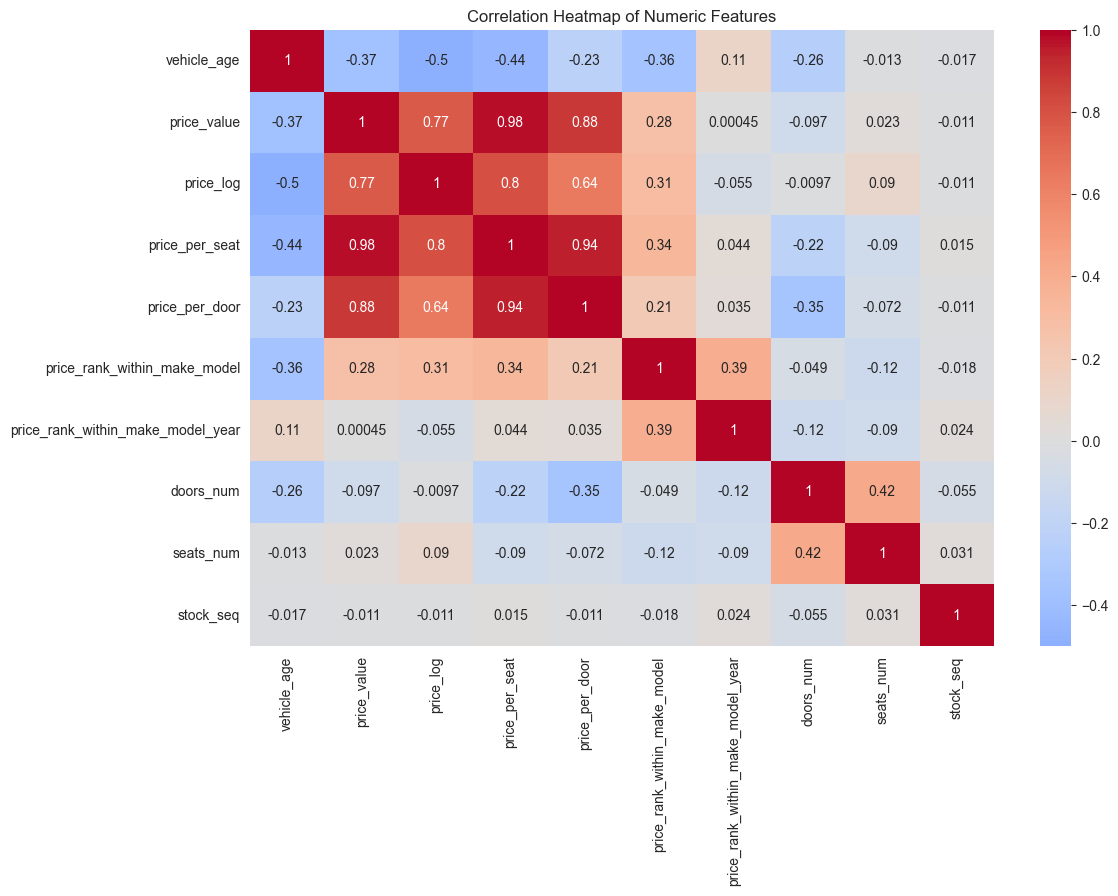

In [39]:
# plot a correlation heatmap of numeric features
numeric_cols = df_clean.select_dtypes(include=np.number).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [40]:
df_clean = df_clean.drop(columns = ['price_per_seat', 'price_per_door', 'price_rank_within_make_model', 'price_rank_within_make_model_year', 'stock_prefix', 'color', 'frame_no_type', 'currency', 'stock_seq', 'is_listing', 'is_hybrid', 'is_electric', 'is_electrified', 'is_vin'])

In [41]:
df_clean.head()
# saving the df clean as a csv file
df_clean.to_csv('data/raw/cars.csv', index=False)

In [42]:
df_clean['vin_region'].unique()

<StringArray>
[             nan,        'Germany',            'USA', 'United Kingdom',
 'Sweden/Finland',   'France/Spain',          'Italy',          'Other',
          'China',          'Japan']
Length: 10, dtype: str

In [43]:
# Define feature columns without highly correlated ones
TARGET = 'price_log'
num_cols = [
    'vehicle_age',
    'doors_num',
    'seats_num',
]

cat_cols = [
    'market_country',
    'stock_country',
    'is_overseas_stock',
    'make_clean',
    'model_clean',
    'age_bucket',
    'fuel_group',
    'transmission_group',
    'drive_group',
    'steering_group',
    'vin_region',
    'body_guess',
]

# Create X and y
feature_cols = num_cols + cat_cols
X = df_clean[feature_cols]
y = df_clean[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {len(feature_cols)} ({len(num_cols)} numeric + {len(cat_cols)} categorical)")

X shape: (950, 15)
y shape: (950,)
Features: 15 (3 numeric + 12 categorical)


In [44]:
df_clean[feature_cols].dtypes

vehicle_age            float64
doors_num              float64
seats_num              float64
market_country             str
stock_country              str
is_overseas_stock         bool
make_clean                 str
model_clean                str
age_bucket            category
fuel_group                 str
transmission_group         str
drive_group                str
steering_group             str
vin_region                 str
body_guess                 str
dtype: object

In [45]:
df_clean[cat_cols].nunique().sort_values(ascending=False)

model_clean           224
make_clean             31
market_country         11
body_guess              9
vin_region              9
age_bucket              6
fuel_group              6
stock_country           5
transmission_group      4
drive_group             3
is_overseas_stock       2
steering_group          2
dtype: int64

In [46]:
from sklearn.model_selection import train_test_split
# split the dara
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (760, 15), (760,)
Test set: (190, 15), (190,)


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
import numpy as np

# High cardinality columns
high_card_cols = ['model_clean', 'make_clean']

# Low cardinality columns (use OneHotEncoder)
low_card_cols = [col for col in cat_cols if col not in high_card_cols]

print(f"High cardinality cols: {high_card_cols}")
print(f"Low cardinality cols: {low_card_cols}")
print(f"Numeric cols: {num_cols}")

# Build the preprocessing pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Function to convert to string
def to_object(X):
    return X.astype(object)

to_object_transformer = FunctionTransformer(
    to_object,
    validate=False,
    feature_names_out="one-to-one",
)

# High cardinality pipeline (Ordinal Encoding)
high_card_pipeline = Pipeline([
    ('to_object', to_object_transformer),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        dtype='int64'
    ))
])

# Low cardinality pipeline (One-Hot Encoding)
low_card_pipeline = Pipeline([
    ('to_object', to_object_transformer),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False,
        min_frequency=1
    ))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('high_card', high_card_pipeline, high_card_cols),
    ('low_card', low_card_pipeline, low_card_cols)
],
remainder='drop'
)

print("Preprocessing pipeline created successfully.")
print(f"Total features to process: {len(num_cols) + len(high_card_cols) + len(low_card_cols)}")

High cardinality cols: ['model_clean', 'make_clean']
Low cardinality cols: ['market_country', 'stock_country', 'is_overseas_stock', 'age_bucket', 'fuel_group', 'transmission_group', 'drive_group', 'steering_group', 'vin_region', 'body_guess']
Numeric cols: ['vehicle_age', 'doors_num', 'seats_num']
Preprocessing pipeline created successfully.
Total features to process: 15


In [49]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor


In [50]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(
        alpha=1.0,
        random_state=42,
    ),
    "Lasso Regression": Lasso(
        alpha=0.1,
        random_state=42,
        max_iter=1000,
    ),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42,
        min_samples_split=5,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1,
        min_samples_split=5,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbosity=0,
    ),
    "KNN": KNeighborsRegressor(
        n_neighbors=5,
        weights='distance',
    ),
}

print(f"Total models to evaluate: {len(models)}")
print(list(models.keys()))

Total models to evaluate: 8
['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'KNN']


In [51]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "neg_mean_absolute_error": "neg_mean_absolute_error",
    "neg_mean_squared_error": "neg_mean_squared_error",
    "neg_root_mean_squared_error": "neg_root_mean_squared_error",
}


def get_pipeline(model):
    return Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


def get_predictions(fitted_pipeline, X):
    return fitted_pipeline.predict(X)


def evaluate_test_set(fitted_pipeline, X_test, y_test):
    y_pred = fitted_pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Calculate MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    metrics = {
        "Test MAE": mae,
        "Test MSE": mse,
        "Test RMSE": rmse,
        "Test MAPE": mape,
        "Test R²": r2,
    }

    return y_pred, None, metrics

In [52]:
# main training loop cell
from sklearn.model_selection import cross_validate
cv_results = {}
trained_pipelines = {}
test_predictions = {}
test_scores = {}
import time

for model_name, model in models.items():
    print(f"Cross-validating {model_name}...", end=" ")

    pipe = get_pipeline(model)
    start_time = time.time()

    cv_scores = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_time = time.time() - start_time

    cv_results[model_name] = {
        "CV R² Mean": cv_scores['test_r2'].mean(),
        "CV R² Std": cv_scores['test_r2'].std(),
        "CV MAE Mean": -cv_scores['test_neg_mean_absolute_error'].mean(),
        "CV MAE Std": cv_scores['test_neg_mean_absolute_error'].std(),
        "CV RMSE Mean": np.sqrt(-cv_scores['test_neg_mean_squared_error'].mean()),
        "CV RMSE Std": np.sqrt(-cv_scores['test_neg_mean_squared_error']).std(),
        "CV Time (s)": round(cv_time, 4),
    }

    fit_start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - fit_start

    y_pred, y_score, test_metrics = evaluate_test_set(pipe, X_test, y_test)

    cv_results[model_name].update(test_metrics)
    cv_results[model_name]["Fit Time Full Train (s)"] = round(fit_time, 4)

    trained_pipelines[model_name] = pipe
    test_predictions[model_name] = y_pred
    test_scores[model_name] = y_score

    print(
        f"CV R² mean: {cv_results[model_name]['CV R² Mean']:.4f}, "
        f"Test RMSE: {cv_results[model_name]['Test RMSE']:.2f}, "
        f"Test R²: {cv_results[model_name]['Test R²']:.4f}"
    )

print('\nAll models cross-validated, fitted, and evaluated successfully!')

Cross-validating Linear Regression... 

D:\Users\user\PycharmProjects\Japan_car_price_prediction_project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


CV R² mean: 0.6654, Test RMSE: 0.51, Test R²: 0.5954
Cross-validating Ridge Regression... 

D:\Users\user\PycharmProjects\Japan_car_price_prediction_project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


CV R² mean: 0.6450, Test RMSE: 0.52, Test R²: 0.5928
Cross-validating Lasso Regression... 

...

CV R² mean: 0.7417, Test RMSE: 0.39, Test R²: 0.7653
Cross-validating XGBoost... 

D:\Users\user\PycharmProjects\Japan_car_price_prediction_project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


CV R² mean: 0.7118, Test RMSE: 0.39, Test R²: 0.7638
Cross-validating KNN... 

D:\Users\user\PycharmProjects\Japan_car_price_prediction_project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


CV R² mean: 0.5198, Test RMSE: 0.57, Test R²: 0.5105

All models cross-validated, fitted, and evaluated successfully!


In [53]:
# the best model is xgboost with CV R² mean: 0.5757, Test RMSE: 9129.59, Test R²: 0.6396

In [54]:
# Results comparison table
results_df = pd.DataFrame(cv_results).T.sort_values(
    "CV R² Mean", ascending=False
)

print("\n" + "=" * 100)
print("MODEL RANKING BY CROSS-VALIDATED F1")
print("=" * 100)
print(results_df.round(4))
print("=" * 100)

best_model_name = results_df.index[0]
best_pipeline = trained_pipelines[best_model_name]

print(f"\n🏆 Best model from CV: {best_model_name}")
print(
    f"CV R² Mean: {results_df.loc[best_model_name, 'CV R² Mean']:.4f} "
    f"+/- {results_df.loc[best_model_name, 'CV R² Std']:.4f}"
)
print(f"Test R²: {results_df.loc[best_model_name, 'Test R²']:.4f}")


MODEL RANKING BY CROSS-VALIDATED F1
                   CV R² Mean  CV R² Std  CV MAE Mean  CV MAE Std  \
Gradient Boosting      0.7417     0.0623       0.3163      0.0179   
XGBoost                0.7118     0.0809       0.3219      0.0219   
Linear Regression      0.6654     0.0533       0.3961      0.0139   
Random Forest          0.6647     0.0718       0.3573      0.0213   
Ridge Regression       0.6450     0.0383       0.4115      0.0174   
KNN                    0.5198     0.0484       0.4104      0.0245   
Decision Tree          0.5056     0.1711       0.4345      0.0281   
Lasso Regression       0.2648     0.0705       0.5789      0.0346   

                   CV RMSE Mean  CV RMSE Std  CV Time (s)  Test MAE  Test MSE  \
Gradient Boosting        0.4829       0.0334       4.1802    0.2793    0.1539   
XGBoost                  0.5159       0.0799       1.0529    0.2909    0.1548   
Linear Regression        0.5558       0.0524      24.7528    0.3870    0.2652   
Random Forest    

In [55]:
from sklearn.metrics import classification_report
best_model_name = results_df.index[0]
best_pipeline = trained_pipelines[best_model_name]
best_y_pred = test_predictions[best_model_name]

print("\n" + "=" * 60)
print(f"BEST MODEL FROM CV: {best_model_name}")
print("=" * 60)




BEST MODEL FROM CV: Gradient Boosting


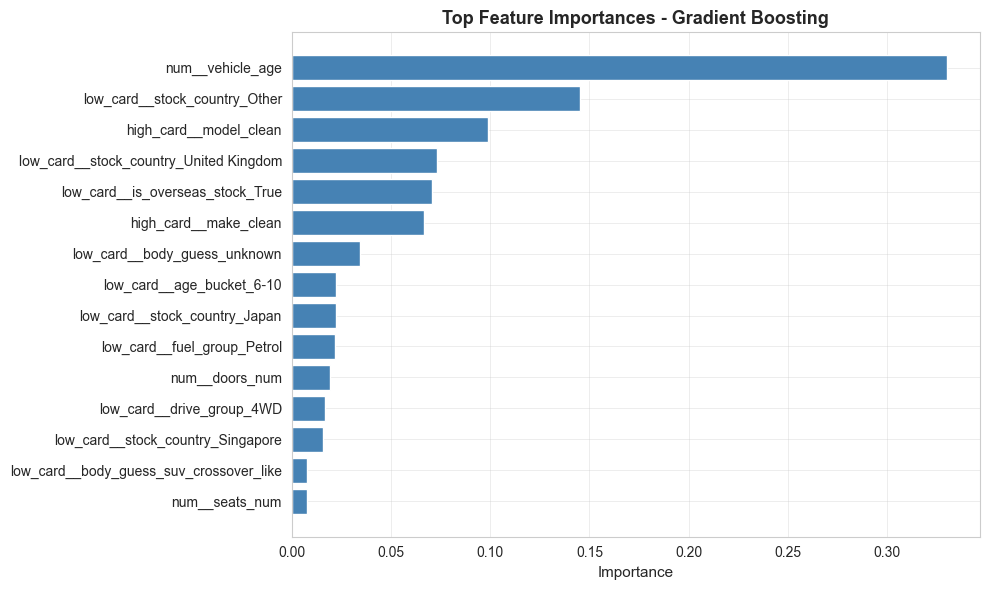


Top Feature Importances:
                                Feature  Importance
                       num__vehicle_age    0.330271
          low_card__stock_country_Other    0.145297
                 high_card__model_clean    0.098929
 low_card__stock_country_United Kingdom    0.072975
       low_card__is_overseas_stock_True    0.070473
                  high_card__make_clean    0.066803
           low_card__body_guess_unknown    0.034613
              low_card__age_bucket_6-10    0.022293
          low_card__stock_country_Japan    0.022077
            low_card__fuel_group_Petrol    0.021831
                         num__doors_num    0.019327
              low_card__drive_group_4WD    0.016967
      low_card__stock_country_Singapore    0.015844
low_card__body_guess_suv_crossover_like    0.007929
                         num__seats_num    0.007539


In [56]:
# best estimator feature importance
best_estimator = best_pipeline.named_steps["model"]

if hasattr(best_estimator, "feature_importances_"):
    importances = best_estimator.feature_importances_

    # Get transformed feature names from the pipeline
    try:
        feature_names = best_pipeline[:-1].get_feature_names_out()
    except Exception as e:
        print(f"Could not get transformed feature names automatically: {e}")
        feature_names = [f"feature_{i}" for i in range(len(importances))]

    # Safety check in case names and importances differ in length
    if len(feature_names) != len(importances):
        print(
            f"Warning: feature name count ({len(feature_names)}) does not match "
            f"importance count ({len(importances)}). Using generic names instead."
        )
        feature_names = [f"feature_{i}" for i in range(len(importances))]

    importance_df = (
        pd.DataFrame(
            {
                "Feature": feature_names,
                "Importance": importances,
            }
        )
        .sort_values("Importance", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df["Feature"][::-1],
        importance_df["Importance"][::-1],
        color="steelblue",
    )
    plt.xlabel("Importance", fontsize=11)
    plt.title(
        f"Top Feature Importances - {best_model_name}",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    print("\nTop Feature Importances:")
    print(importance_df.to_string(index=False))

else:
    print(
        f"Note: {best_model_name} does not provide built-in feature "
        f"importance scores."
    )